Dataset: https://www.kaggle.com/datasets/ludocielbeckett/health-risk-prediction-anonymized-real-data/data

# Import libraries

In [12]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import joblib

# Data analysis

In [3]:
# Load data
df = pd.read_csv('../../../data/Health_Risk_Dataset.csv')
df.columns=df.columns.str.lower()
df.head()

,patient_id,respiratory_rate,oxygen_saturation,o2_scale,systolic_bp,heart_rate,temperature,consciousness,on_oxygen,risk_level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1000 non-null   str    
 1   respiratory_rate   1000 non-null   int64  
 2   oxygen_saturation  1000 non-null   int64  
 3   o2_scale           1000 non-null   int64  
 4   systolic_bp        1000 non-null   int64  
 5   heart_rate         1000 non-null   int64  
 6   temperature        1000 non-null   float64
 7   consciousness      1000 non-null   str    
 8   on_oxygen          1000 non-null   int64  
 9   risk_level         1000 non-null   str    
dtypes: float64(1), int64(6), str(3)
memory usage: 78.3 KB


In [5]:
df['risk_level'].value_counts()

risk_level
Medium    306
High      279
Low       255
Normal    160
Name: count, dtype: int64

In [5]:
df.isnull().sum()

patient_id           0
respiratory_rate     0
oxygen_saturation    0
o2_scale             0
systolic_bp          0
heart_rate           0
temperature          0
consciousness        0
on_oxygen            0
risk_level           0
dtype: int64

In [6]:
df.describe()

,respiratory_rate,oxygen_saturation,o2_scale,systolic_bp,heart_rate,temperature,on_oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


# Preprocessing

Change column "Consciousness" from Categorical to Numerical

In [7]:
df['consciousness'] = df['consciousness'].str.upper().str.strip()
conscious_map = {'A': 0, 'V': 1, 'P': 2, 'C': 3, 'U': 4}
df['consciousness'] = df['consciousness'].map(conscious_map)

print(df['consciousness'].isnull().sum())

0


In [8]:
# drop patient_id since it does not influence the health risk
df.drop('patient_id', axis=1, inplace=True)

# encode the target risk level
le = LabelEncoder()
df['risk_level'] = le.fit_transform(df['risk_level'])

scaler = StandardScaler()
num_cols = df.drop('risk_level', axis=1).select_dtypes(include='number').columns
df[num_cols] = scaler.fit_transform(df[num_cols])

Cross-correlation

<Axes: >

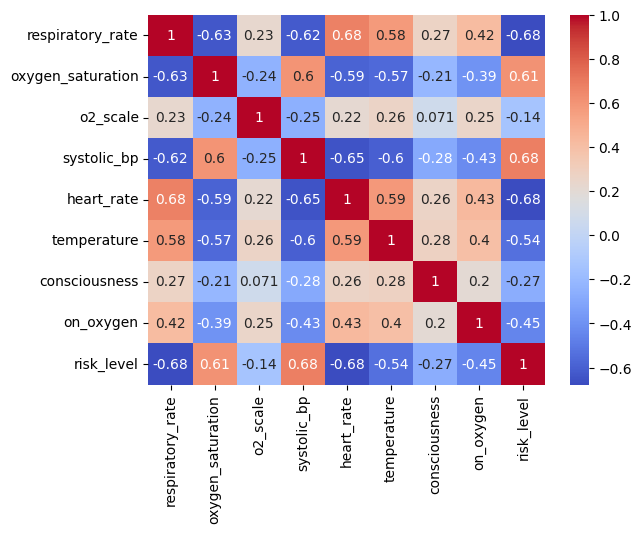

In [9]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# Training and evaluating model

In [43]:
X = df.drop('risk_level', axis=1)
y = df['risk_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### XGBoost

In [12]:
model = XGBClassifier(objective='multi:softprob', num_class=4, eval_metric='mlogloss')
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [13]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        56
           1       0.96      0.92      0.94        51
           2       0.91      0.95      0.93        61
           3       1.00      0.97      0.98        32

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



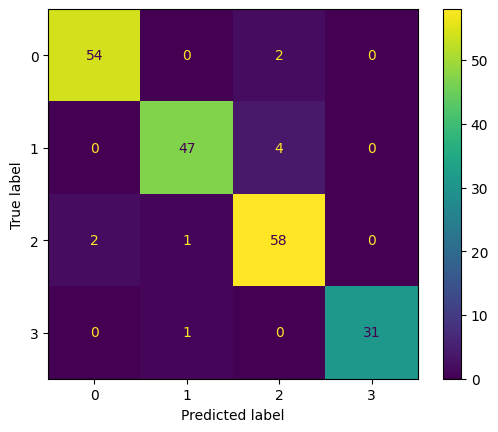

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 95.00%


### Random Forest

In [44]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        56
           1       0.96      0.92      0.94        51
           2       0.91      0.98      0.94        61
           3       1.00      0.97      0.98        32

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



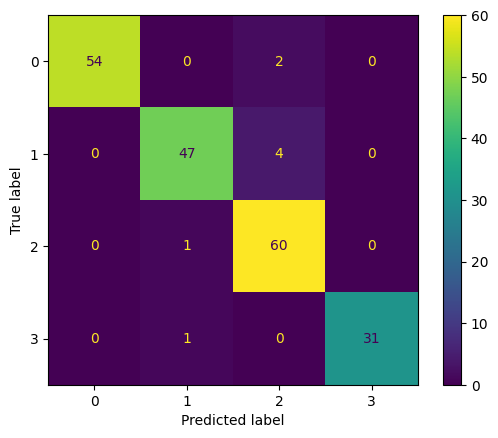

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 96.00%


In [28]:
cm      = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
f1      = f1_score(y_test, y_pred, average="macro")

print(f"Confusion Matrix:\n{cm}")
print(f"\nROC-AUC : {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")

cv_scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
print(f"\n5-Fold Cross-Val F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Confusion Matrix:
[[54  0  2  0]
 [ 0 47  4  0]
 [ 0  1 60  0]
 [ 0  1  0 31]]

ROC-AUC : 0.9974
F1 Score: 0.9627

5-Fold Cross-Val F1: 0.9695 ± 0.0101


# Export model

In [ ]:
joblib.dump(model, "cloud_model.1.0.0.pkl")

['random_forest_model_0.1.pkl']

In [13]:
# Save the scaler 
joblib.dump(scaler, "standard_scaler.pkl")

['standard_scaler.pkl']

In [10]:
feature_cols = df.columns[:-1]
feature_cols

Index(['respiratory_rate', 'oxygen_saturation', 'o2_scale', 'systolic_bp',
       'heart_rate', 'temperature', 'consciousness', 'on_oxygen'],
      dtype='str')

In [ ]:
metadata = {
    "model_version"  : "1.0.0",
    "model_type"     : "RandomForestClassifier",
    "feature_columns": feature_cols,
    "target_column"  : "anomaly",
    # "optimal_threshold": round(float(best_thresh), 3),
    "normal_ranges"  : {
        "systolic_bp" : {"min": 90,  "max": 139},
        "heart_rate"              : {"min": 55,  "max": 100},
        "temperature"        : {"min": 36.0,"max": 37.5},
        "oxygen_saturation"       : {"min": 95,  "max": 100},
        "respiratory_rate"        : {"min": 12, "max":25},
        # "o2_scale"                : {},
    },
    "performance": {
    "roc_auc"        : round(roc_auc, 4),
    "f1_score"       : round(f1, 4),
    "cv_f1_mean"     : round(float(cv_scores.mean()), 4),
    "cv_f1_std"      : round(float(cv_scores.std()),  4),
    },
    "edge_deployment": {
    "target_device" : " esp32",
    "inference_format": "sklearn Pipeline (.pkl)",
    "real_device_export": "Convert via tf.lite or onnxmltools for hardware",
    },
}

with open("metadata_cloud_model.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [ ]:
importances = model.feature_importances_
feat_imp = sorted(zip(df.columns[:-1], importances), key=lambda x: -x[1])
print("\n Feature Importances:")
for feat, imp in feat_imp:
    bar = "█" * int(imp * 40)
    print(f"  {feat:<32} {imp:.4f}  {bar}")


 Feature Importances:
  Oxygen_Saturation                0.2176  ████████
  Heart_Rate                       0.1957  ███████
  Respiratory_Rate                 0.1873  ███████
  Systolic_BP                      0.1789  ███████
  Temperature                      0.1747  ██████
  On_Oxygen                        0.0290  █
  O2_Scale                         0.0086  
  Consciousness                    0.0083  
